In [1]:
import sys
print(sys.version)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [2]:
import scipy
import numpy
import matplotlib
import pandas
import sklearn

print('python: {}'.format(sys.version))
print('scipy: {}'.format(scipy.__version__))
print('numpy: {}'.format(numpy.__version__))
print('matplotlib: {}'.format(matplotlib.__version__))
print('pandas: {}'.format(pandas.__version__))
print('sklearn: {}'.format(sklearn.__version__))


python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
scipy: 1.17.1
numpy: 2.4.6
matplotlib: 3.11.0
pandas: 3.0.3
sklearn: 1.9.0


In [3]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn import model_selection
from sklearn.base import clone
from collections import Counter

In [4]:
#load data
names = ["sepal_length", "sepal_width", "petal_length", "petal_width", "class"]
dataset = pandas.read_csv("iris-data/iris.data", names=names)

In [5]:
#shape
print(dataset.shape)

(150, 5)


In [6]:
#head
print(dataset.head(10))

   sepal_length  sepal_width  petal_length  petal_width        class
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
5           5.4          3.9           1.7          0.4  Iris-setosa
6           4.6          3.4           1.4          0.3  Iris-setosa
7           5.0          3.4           1.5          0.2  Iris-setosa
8           4.4          2.9           1.4          0.2  Iris-setosa
9           4.9          3.1           1.5          0.1  Iris-setosa


In [7]:
#describe
print(dataset.describe())

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


In [8]:
# distribution
print(dataset.groupby('class').size())

class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64


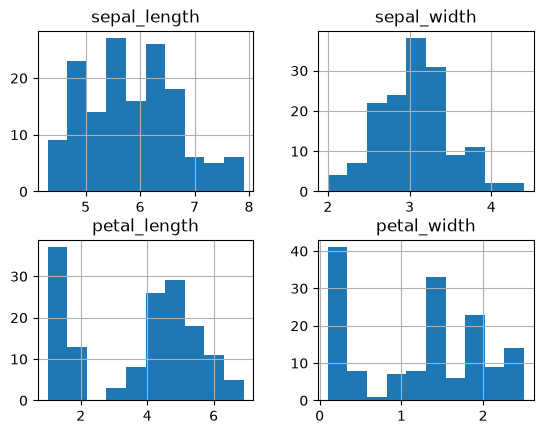

In [9]:
#histograms
dataset.hist()
plt.show()

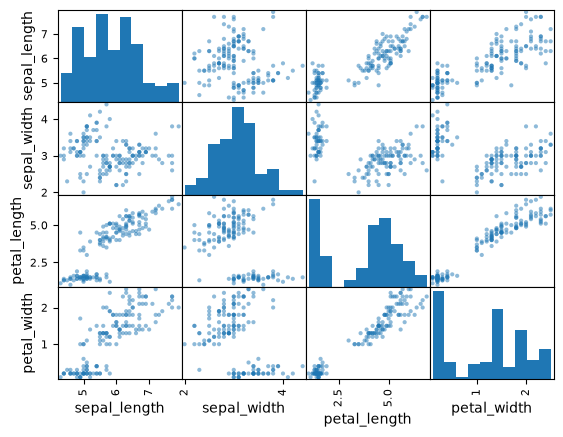

In [10]:
#scatterplot
scatter_matrix(dataset)
plt.show()

In [11]:
# split validation set
array = dataset.values

X = array[:, 0:4]
Y = array[:, 4]

validation_size = 0.2
seed = 7

# Original random split
X_train, X_validation, Y_train, Y_validation = model_selection.train_test_split(
    X,
    Y,
    test_size=validation_size,
    random_state=seed
)

# Balanced / stratified split
X_train_balanced, X_validation_balanced, Y_train_balanced, Y_validation_balanced = model_selection.train_test_split(
    X,
    Y,
    test_size=validation_size,
    random_state=seed,
    stratify=Y
)

In [12]:
#test options
scoring = 'accuracy'

In [13]:
models = []
models.append(('LR', LogisticRegression()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('SVM', SVC()))

In [14]:
for name, model in models:
    print(name)
    print(model.get_params())
    print()

LR
{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 100, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

KNN
{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}

SVM
{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': 'deprecated', 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}



In [15]:
#evaluate as lesson - random split
results_1 = []
names_1 = []
for name, model in models:
    kfold = model_selection.KFold(n_splits=10, shuffle=True, random_state = seed)
    cv_results = model_selection.cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    results_1.append(cv_results)
    names_1.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

LR: 0.983333 (0.033333)
KNN: 0.983333 (0.033333)
SVM: 0.983333 (0.033333)


In [16]:
#evaluate stratified split
results_2 = []
names_2 = []
for name, model in models:
    kfold = model_selection.KFold(n_splits=10, shuffle=True, random_state = seed)
    cv_results = model_selection.cross_val_score(model, X_train_balanced, Y_train_balanced, cv=kfold, scoring=scoring)
    results_2.append(cv_results)
    names_2.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

LR: 0.950000 (0.055277)
KNN: 0.950000 (0.066667)
SVM: 0.958333 (0.041667)


In [ ]:
#interesting to note that at this stage, the stratified set performs less well, this could be due to the random model overfitting the data

In [17]:
# Validate
for name, model in models:
    model.fit(X_train, Y_train)
    predictions_1 = model.predict(X_validation)
    print(name)
    print(accuracy_score(Y_validation, predictions_1))
    print(classification_report(Y_validation, predictions_1))

LR
0.8666666666666667
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         7
Iris-versicolor       0.83      0.83      0.83        12
 Iris-virginica       0.82      0.82      0.82        11

       accuracy                           0.87        30
      macro avg       0.88      0.88      0.88        30
   weighted avg       0.87      0.87      0.87        30

KNN
0.9
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         7
Iris-versicolor       0.85      0.92      0.88        12
 Iris-virginica       0.90      0.82      0.86        11

       accuracy                           0.90        30
      macro avg       0.92      0.91      0.91        30
   weighted avg       0.90      0.90      0.90        30

SVM
0.8666666666666667
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         7
Iris-versicolor       0.83  

In [18]:
# Validate stratified split
for name, model in models:
    fitted_model = clone(model)
    fitted_model.fit(X_train_balanced, Y_train_balanced)

    predictions_2 = fitted_model.predict(X_validation_balanced)

    print(name)
    print(accuracy_score(Y_validation_balanced, predictions_2))
    print(classification_report(Y_validation_balanced, predictions_2))

LR
1.0
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

KNN
1.0
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

SVM
0.9666666666666667
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.91      1.00      0

In [19]:
# splitting the data for the training set results in overall higher scores in all measures. This highlights the importance of segmenting data when training.

In [25]:
random_validation_scores = []
stratified_validation_scores = []
model_names = []

# Random split final validation scores
for name, model in models:
    model.fit(X_train, Y_train)
    predictions_1 = model.predict(X_validation)
    score_1 = accuracy_score(Y_validation, predictions_1)

    random_validation_scores.append(score_1)
    model_names.append(name)

# Stratified split final validation scores
for name, model in models:
    model.fit(X_train_balanced, Y_train_balanced)
    predictions_2 = model.predict(X_validation_balanced)
    score_2 = accuracy_score(Y_validation_balanced, predictions_2)

    stratified_validation_scores.append(score_2)

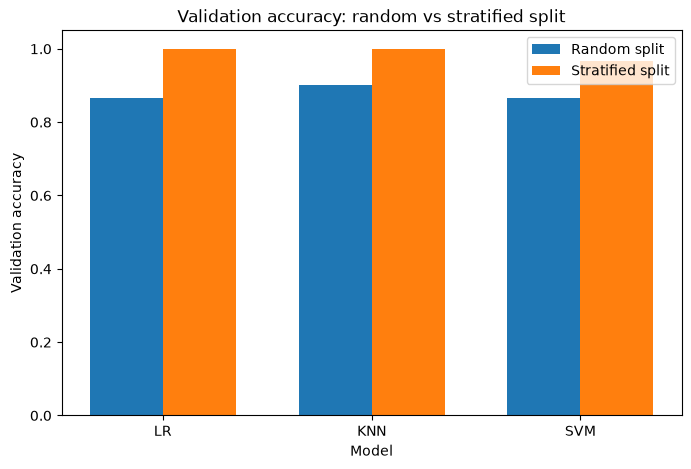

In [27]:
x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, random_validation_scores, width, label="Random split")
plt.bar(x + width/2, stratified_validation_scores, width, label="Stratified split")

plt.title("Validation accuracy: random vs stratified split")
plt.ylabel("Validation accuracy")
plt.xlabel("Model")
plt.xticks(x, model_names)
plt.ylim(0, 1.05)
plt.legend()
plt.show()